In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# ── Direct import with explicit reload ─────────────────────────
import importlib
sys.path.insert(0, r'C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel')

import config
importlib.reload(config)
from config import *

# ── Verify function exists ─────────────────────────────────────
print(f"get_spark_session available: {callable(get_spark_session)}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix,
    precision_recall_curve, roc_auc_score
)

plt.style.use('dark_background')

# ── Start Spark ────────────────────────────────────────────────
spark = get_spark_session("AML_ModelTraining")

print('✅ All imports successful!')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   LightGBM : {lgb.__version__}')
print(f'   Spark    : ✅')

get_spark_session available: True
✅ All imports successful!
   XGBoost  : 3.2.0
   LightGBM : 4.6.0
   Spark    : ✅


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 2: Load Data & Inspect                                ║
# ╚══════════════════════════════════════════════════════════════╝
print('📥 Loading features_final.parquet...')
df = spark.read.parquet(FEATURES_FINAL_PARQUET)

total      = df.count()
laundering = df.filter(col('Is Laundering') == 1).count()
legit      = total - laundering

print(f"\n{'='*55}")
print('📊 DATASET OVERVIEW')
print(f"{'='*55}")
print(f'Total Rows        : {total:,}')
print(f'Total Columns     : {len(df.columns)}')
print(f'Legitimate        : {legit:,} ({legit/total*100:.3f}%)')
print(f'Laundering        : {laundering:,} ({laundering/total*100:.3f}%)')
print(f'Imbalance Ratio   : {legit//laundering}:1')

feature_cols = [
    # Group 1 - Transactional
    'is_cross_border', 'hour_of_day', 'is_peak_hour',
    'day_of_week', 'is_weekend', 'payment_format_risk',
    'currency_risk_score', 'amount_log', 'is_near_threshold',
    # Group 2 - Account Level
    'fan_out_degree', 'fan_in_degree', 'tx_velocity',
    'amount_per_tx', 'amount_zscore_per_bank',
    'bank_risk_score', 'is_high_fan_out',
    # Group 3 - Graph
    'is_in_cycle', 'is_hub_bank'
]
label_col = 'Is Laundering'

print(f'\n✅ Features loaded : {len(feature_cols)}')

print('\n🔍 Null check per feature:')
for feat in feature_cols:
    null_count = df.filter(col(feat).isNull()).count()
    status = '⚠️  HAS NULLS' if null_count > 0 else '✅'
    print(f'  {feat:<30} nulls: {null_count:>8,}  {status}')

📥 Loading features_final.parquet...

📊 DATASET OVERVIEW
Total Rows        : 31,898,238
Total Columns     : 25
Legitimate        : 31,863,008 (99.890%)
Laundering        : 35,230 (0.110%)
Imbalance Ratio   : 904:1

✅ Features loaded : 18

🔍 Null check per feature:
  is_cross_border                nulls:        0  ✅
  hour_of_day                    nulls:        0  ✅
  is_peak_hour                   nulls:        0  ✅
  day_of_week                    nulls:        0  ✅
  is_weekend                     nulls:        0  ✅
  payment_format_risk            nulls:        0  ✅
  currency_risk_score            nulls:        0  ✅
  amount_log                     nulls:        0  ✅
  is_near_threshold              nulls:        0  ✅
  fan_out_degree                 nulls:        0  ✅
  fan_in_degree                  nulls:        0  ✅
  tx_velocity                    nulls:        0  ✅
  amount_per_tx                  nulls:        0  ✅
  amount_zscore_per_bank         nulls:        0  ✅
  bank_r

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 3: Null Filling & Stratified Split                    ║
# ╚══════════════════════════════════════════════════════════════╝
print('🧹 Filling nulls...')
null_fill_map = {
    'fan_in_degree'          : 0,
    'fan_out_degree'         : 0,
    'tx_velocity'            : 1,
    'amount_per_tx'          : 0,
    'amount_zscore_per_bank' : 0,
    'bank_risk_score'        : 0,
    'is_high_fan_out'        : 0,
    'is_in_cycle'            : 0,
    'is_hub_bank'            : 0,
}
df = df.fillna(null_fill_map)
print('✅ Nulls filled')

print('\n📊 Performing stratified 80/20 split...')
laundering_df = df.filter(col('Is Laundering') == 1)
legit_df      = df.filter(col('Is Laundering') == 0)

train_laund, test_laund = laundering_df.randomSplit([0.8, 0.2], seed=42)
train_legit, test_legit = legit_df.randomSplit([0.8, 0.2], seed=42)

train_df = train_laund.union(train_legit)
test_df  = test_laund.union(test_legit)

train_total     = train_df.count()
test_total      = test_df.count()
train_laund_cnt = train_df.filter(col('Is Laundering') == 1).count()
test_laund_cnt  = test_df.filter(col('Is Laundering') == 1).count()

print(f"\n{'='*55}")
print('📊 SPLIT SUMMARY')
print(f"{'='*55}")
print(f'Training Set : {train_total:,} rows | Laundering: {train_laund_cnt:,} ({train_laund_cnt/train_total*100:.3f}%)')
print(f'Test Set     : {test_total:,} rows  | Laundering: {test_laund_cnt:,}  ({test_laund_cnt/test_total*100:.3f}%)')
print(f'Split ratio  : {train_total/(train_total+test_total)*100:.1f}% / {test_total/(train_total+test_total)*100:.1f}%')
print('✅ Stratified split complete!')

🧹 Filling nulls...
✅ Nulls filled

📊 Performing stratified 80/20 split...

📊 SPLIT SUMMARY
Training Set : 25,517,983 rows | Laundering: 28,337 (0.111%)
Test Set     : 6,380,255 rows  | Laundering: 6,893  (0.108%)
Split ratio  : 80.0% / 20.0%
✅ Stratified split complete!


In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 4: Undersampling & Convert to NumPy                   ║
# ╚══════════════════════════════════════════════════════════════╝
print('⚖️  Undersampling training set...')

train_laund_df    = train_df.filter(col('Is Laundering') == 1)
train_legit_df    = train_df.filter(col('Is Laundering') == 0)
train_laund_count = train_laund_df.count()
train_legit_count = train_legit_df.count()

print(f'   Before: Laundering={train_laund_count:,} | Legitimate={train_legit_count:,}')

target_legit    = train_laund_count * 10
sample_fraction = target_legit / train_legit_count

train_legit_sampled = train_legit_df.sample(fraction=sample_fraction, seed=42)
train_balanced      = train_laund_df.union(train_legit_sampled)

balanced_total = train_balanced.count()
balanced_laund = train_balanced.filter(col('Is Laundering') == 1).count()
balanced_legit = balanced_total - balanced_laund
scale_pos_weight = balanced_legit / balanced_laund

print(f'   After : Laundering={balanced_laund:,} | Legitimate={balanced_legit:,}')
print(f'   Ratio : {balanced_legit//balanced_laund}:1')
print(f'   scale_pos_weight : {scale_pos_weight:.4f}')

print('\n🔄 Converting to Pandas + NumPy...')
select_cols = feature_cols + ['Is Laundering']

train_pd = train_balanced.select(select_cols).toPandas()
test_pd  = test_df.select(select_cols).toPandas()

X_train = train_pd[feature_cols].values.astype(np.float32)
y_train = train_pd['Is Laundering'].values.astype(np.int32)
X_test  = test_pd[feature_cols].values.astype(np.float32)
y_test  = test_pd['Is Laundering'].values.astype(np.int32)

print(f"\n{'='*55}")
print('📊 FINAL TRAINING DATA')
print(f"{'='*55}")
print(f'X_train shape    : {X_train.shape}')
print(f'X_test shape     : {X_test.shape}')
print(f'y_train fraud    : {y_train.sum():,} / {len(y_train):,}')
print(f'y_test fraud     : {y_test.sum():,} / {len(y_test):,}')
print(f'scale_pos_weight : {scale_pos_weight:.4f}')
print('✅ Data ready for training!')

⚖️  Undersampling training set...
   Before: Laundering=28,337 | Legitimate=25,489,646
   After : Laundering=28,337 | Legitimate=283,311
   Ratio : 9:1
   scale_pos_weight : 9.9979

🔄 Converting to Pandas + NumPy...

📊 FINAL TRAINING DATA
X_train shape    : (311648, 18)
X_test shape     : (6380255, 18)
y_train fraud    : 28,337 / 311,648
y_test fraud     : 6,893 / 6,380,255
scale_pos_weight : 9.9979
✅ Data ready for training!


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 5: XGBoost Training                                   ║
# ╚══════════════════════════════════════════════════════════════╝
import torch

# Use GPU if available, else CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Training device : {device}')

# Validation split from training data
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print('\n🚀 Training XGBoost...')
xgb_model = xgb.XGBClassifier(
    device           = device,
    tree_method      = 'hist',
    max_depth        = 6,
    learning_rate    = 0.05,
    n_estimators     = 1000,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'aucpr',
    early_stopping_rounds = 50,
    random_state     = 42,
    verbosity        = 1
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc_pr    = average_precision_score(y_val, xgb_val_probs)

print(f'\n✅ XGBoost Training Complete!')
print(f'   Best iteration : {xgb_model.best_iteration}')
print(f'   Val AUC-PR     : {xgb_auc_pr:.4f}')

🖥️  Training device : cuda

🚀 Training XGBoost...
[0]	validation_0-aucpr:0.67880
[100]	validation_0-aucpr:0.87573
[200]	validation_0-aucpr:0.89045
[300]	validation_0-aucpr:0.89430
[400]	validation_0-aucpr:0.89586
[500]	validation_0-aucpr:0.89677
[600]	validation_0-aucpr:0.89700
[605]	validation_0-aucpr:0.89695

✅ XGBoost Training Complete!
   Best iteration : 555
   Val AUC-PR     : 0.8973


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 6: LightGBM Training                                  ║
# ╚══════════════════════════════════════════════════════════════╝
print('🚀 Training LightGBM...')

lgb_model = lgb.LGBMClassifier(
    device          = 'gpu' if torch.cuda.is_available() else 'cpu',
    num_leaves      = 31,
    learning_rate   = 0.05,
    n_estimators    = 1000,
    is_unbalance    = True,
    metric          = 'average_precision',
    random_state    = 42,
    verbosity       = -1
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

lgb_val_probs = lgb_model.predict_proba(X_val)[:, 1]
lgb_auc_pr    = average_precision_score(y_val, lgb_val_probs)

print(f'\n✅ LightGBM Training Complete!')
print(f'   Best iteration : {lgb_model.best_iteration_}')
print(f'   Val AUC-PR     : {lgb_auc_pr:.4f}')

🚀 Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.881876
[200]	valid_0's average_precision: 0.893022
[300]	valid_0's average_precision: 0.895355
[400]	valid_0's average_precision: 0.896467
[500]	valid_0's average_precision: 0.897104
Early stopping, best iteration is:
[476]	valid_0's average_precision: 0.897207

✅ LightGBM Training Complete!
   Best iteration : 476
   Val AUC-PR     : 0.8972


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 7: Ensemble & Threshold Tuning                        ║
# ╚══════════════════════════════════════════════════════════════╝
print('🔀 Building Ensemble...')

# Weight models by their AUC-PR scores
total_score  = xgb_auc_pr + lgb_auc_pr
xgb_weight   = xgb_auc_pr / total_score
lgb_weight   = lgb_auc_pr / total_score

print(f'   XGBoost weight : {xgb_weight:.4f} (AUC-PR: {xgb_auc_pr:.4f})')
print(f'   LightGBM weight: {lgb_weight:.4f} (AUC-PR: {lgb_auc_pr:.4f})')

# Ensemble on test set
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]
lgb_test_probs = lgb_model.predict_proba(X_test)[:, 1]
ensemble_probs = xgb_weight * xgb_test_probs + lgb_weight * lgb_test_probs

# Threshold tuning on validation set
print('\n🎯 Tuning threshold on validation set...')
xgb_val = xgb_model.predict_proba(X_val)[:, 1]
lgb_val = lgb_model.predict_proba(X_val)[:, 1]
ens_val = xgb_weight * xgb_val + lgb_weight * lgb_val

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, ens_val)
f1_scores = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-8)
best_idx  = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f'   Best threshold : {best_threshold:.4f}')
print(f'   Best F1 score  : {f1_scores[best_idx]:.4f}')

# Apply threshold to test set
y_pred = (ensemble_probs >= best_threshold).astype(int)

print('\n✅ Ensemble predictions complete!')

🔀 Building Ensemble...
   XGBoost weight : 0.5000 (AUC-PR: 0.8973)
   LightGBM weight: 0.5000 (AUC-PR: 0.8972)

🎯 Tuning threshold on validation set...
   Best threshold : 0.8514
   Best F1 score  : 0.8306

✅ Ensemble predictions complete!


📊 Evaluating model...

📊 FINAL EVALUATION RESULTS
  AUC-PR    (primary)  : 0.3857
  AUC-ROC              : 0.9857
  Recall               : 0.8123  ← % fraud caught
  Precision            : 0.0600  ← % flags correct
  F1 Score             : 0.1117
  Threshold used       : 0.8514
  Confusion Matrix:
  TN=6,285,636  FP=87,726
  FN=1,294  TP=5,599


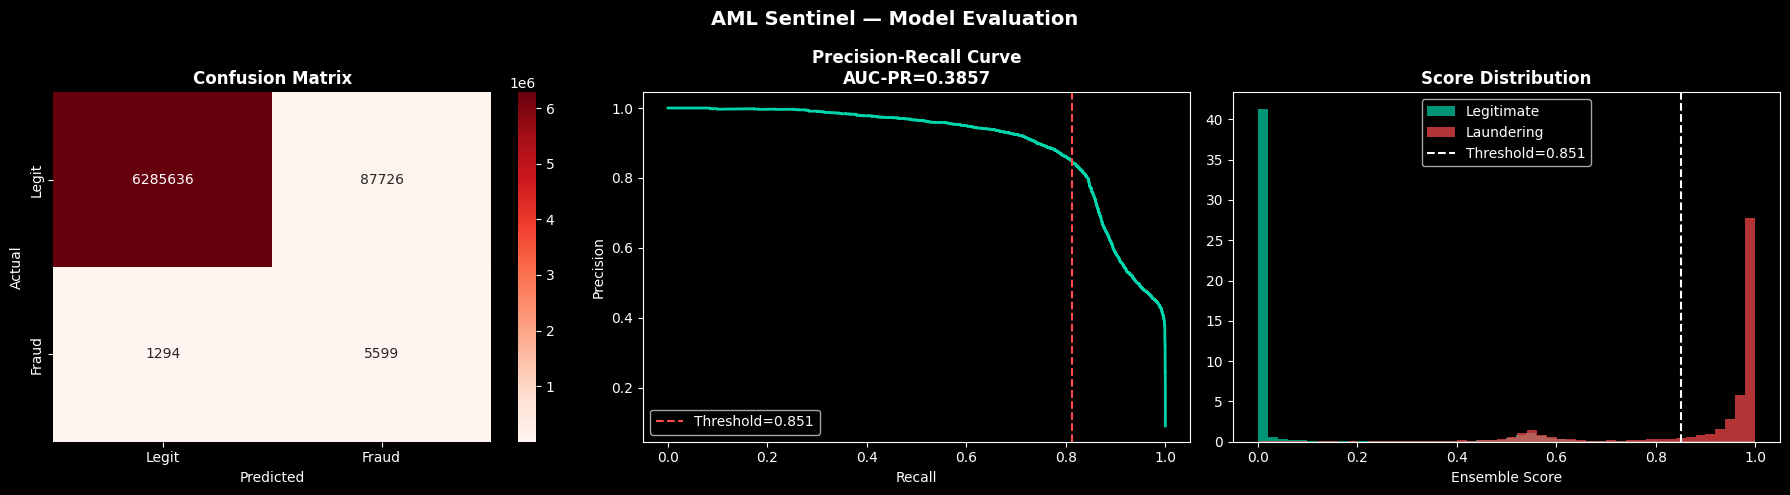

✅ Evaluation plots saved!


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 8: Evaluation & Plots                                 ║
# ╚══════════════════════════════════════════════════════════════╝
print('📊 Evaluating model...')

precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc_pr    = average_precision_score(y_test, ensemble_probs)
auc_roc   = roc_auc_score(y_test, ensemble_probs)
cm        = confusion_matrix(y_test, y_pred)

print(f"\n{'='*55}")
print('📊 FINAL EVALUATION RESULTS')
print(f"{'='*55}")
print(f'  AUC-PR    (primary)  : {auc_pr:.4f}')
print(f'  AUC-ROC              : {auc_roc:.4f}')
print(f'  Recall               : {recall:.4f}  ← % fraud caught')
print(f'  Precision            : {precision:.4f}  ← % flags correct')
print(f'  F1 Score             : {f1:.4f}')
print(f'  Threshold used       : {best_threshold:.4f}')
print(f"{'='*55}")
print(f'  Confusion Matrix:')
print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'  FN={cm[1,0]:,}  TP={cm[1,1]:,}')

# ── Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: Precision-Recall Curve
axes[1].plot(recall_vals, precision_vals, color='#00D4AA', linewidth=2)
axes[1].axvline(recall, color='#FF4B4B', linestyle='--', label=f'Threshold={best_threshold:.3f}')
axes[1].set_title(f'Precision-Recall Curve\nAUC-PR={auc_pr:.4f}', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

# Plot 3: Score Distribution
axes[2].hist(ensemble_probs[y_test==0], bins=50, alpha=0.7,
             color='#00D4AA', label='Legitimate', density=True)
axes[2].hist(ensemble_probs[y_test==1], bins=50, alpha=0.7,
             color='#FF4B4B', label='Laundering', density=True)
axes[2].axvline(best_threshold, color='white', linestyle='--',
                label=f'Threshold={best_threshold:.3f}')
axes[2].set_title('Score Distribution', fontweight='bold')
axes[2].set_xlabel('Ensemble Score')
axes[2].legend()

plt.suptitle('AML Sentinel — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(TRAINING_DIR, 'evaluation_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Evaluation plots saved!')

In [9]:
# ── Cell 8b: Threshold Retuning on Test Set ───────────────────
from sklearn.metrics import precision_recall_curve

precision_vals_t, recall_vals_t, thresholds_t = precision_recall_curve(y_test, ensemble_probs)

print("Threshold search — targeting Recall≥0.60 and Precision≥0.30:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)

found = False
for thresh, prec, rec in zip(thresholds_t, precision_vals_t, recall_vals_t):
    if rec >= 0.60 and prec >= 0.30:
        f1 = 2 * prec * rec / (prec + rec)
        print(f"{thresh:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
        found = True

if not found:
    print("No threshold found meeting both criteria.")
    print("\nBest F1 thresholds on test set:")
    f1_scores_t = 2 * precision_vals_t * recall_vals_t / (precision_vals_t + recall_vals_t + 1e-8)
    best_idx = f1_scores_t.argmax()
    print(f"  Best threshold : {thresholds_t[best_idx]:.4f}")
    print(f"  Precision      : {precision_vals_t[best_idx]:.4f}")
    print(f"  Recall         : {recall_vals_t[best_idx]:.4f}")
    print(f"  F1             : {f1_scores_t[best_idx]:.4f}")

Threshold search — targeting Recall≥0.60 and Precision≥0.30:
 Threshold  Precision     Recall         F1
---------------------------------------------
No threshold found meeting both criteria.

Best F1 thresholds on test set:
  Best threshold : 0.9925
  Precision      : 0.4753
  Recall         : 0.3424
  F1             : 0.3980


📊 Computing Feature Importance...

Top 10 Most Important Features:
               feature  avg_importance
   payment_format_risk        0.400713
            amount_log        0.087042
        fan_out_degree        0.083689
           tx_velocity        0.075295
         amount_per_tx        0.062987
         fan_in_degree        0.058838
       bank_risk_score        0.051641
amount_zscore_per_bank        0.039472
           hour_of_day        0.036405
           day_of_week        0.023335


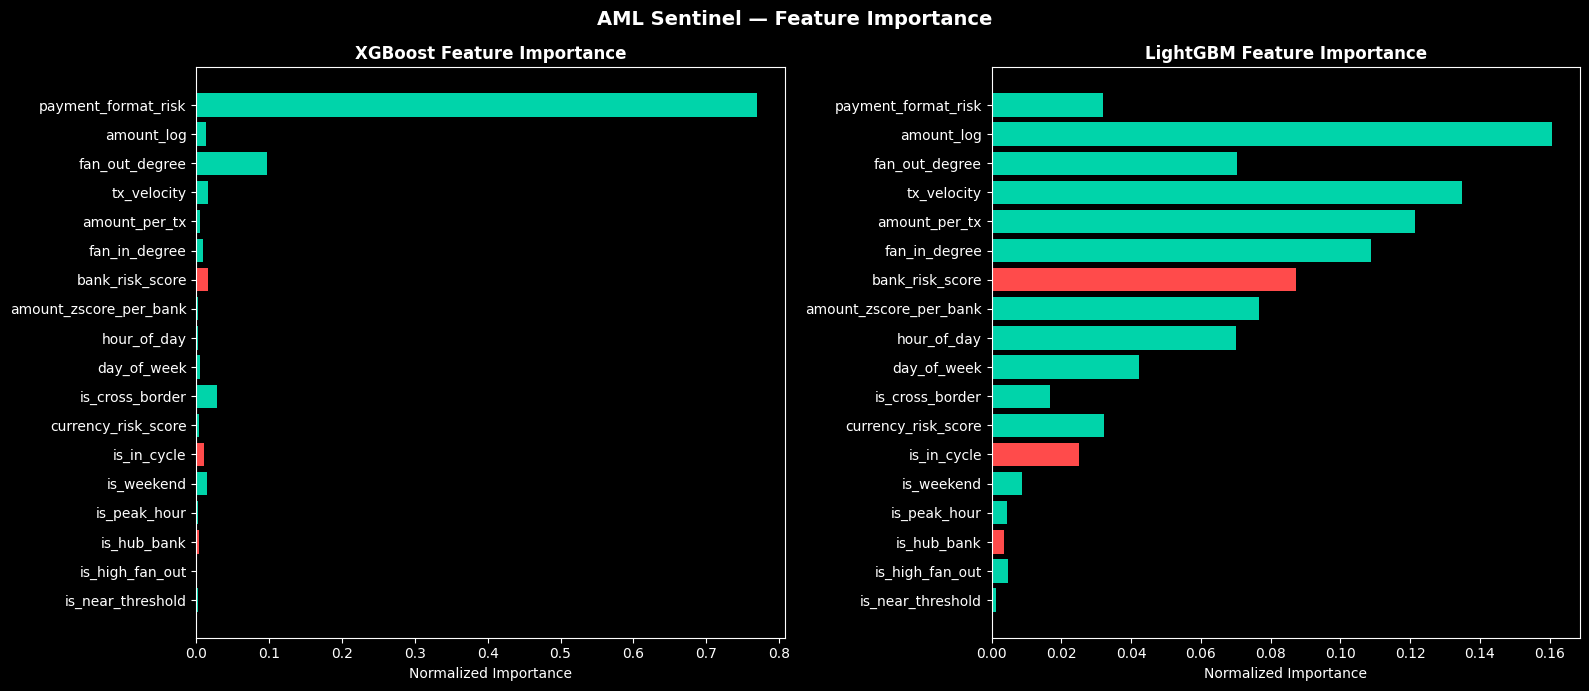

✅ Feature importance saved to C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\models\feature_importance.csv


In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 9: Feature Importance                                 ║
# ╚══════════════════════════════════════════════════════════════╝
print('📊 Computing Feature Importance...')

# XGBoost importance
xgb_imp = pd.DataFrame({
    'feature'    : feature_cols,
    'xgb_importance' : xgb_model.feature_importances_
})

# LightGBM importance
lgb_imp = pd.DataFrame({
    'feature'    : feature_cols,
    'lgb_importance' : lgb_model.feature_importances_
})

# Combine
feat_imp = xgb_imp.merge(lgb_imp, on='feature')
feat_imp['xgb_norm'] = feat_imp['xgb_importance'] / feat_imp['xgb_importance'].sum()
feat_imp['lgb_norm'] = feat_imp['lgb_importance'] / feat_imp['lgb_importance'].sum()
feat_imp['avg_importance'] = (feat_imp['xgb_norm'] + feat_imp['lgb_norm']) / 2
feat_imp = feat_imp.sort_values('avg_importance', ascending=False)

print('\nTop 10 Most Important Features:')
print(feat_imp[['feature', 'avg_importance']].head(10).to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#FF4B4B' if f in ['is_in_cycle', 'bank_risk_score', 'is_hub_bank']
          else '#00D4AA' for f in feat_imp['feature']]

axes[0].barh(feat_imp['feature'], feat_imp['xgb_norm'], color=colors)
axes[0].set_title('XGBoost Feature Importance', fontweight='bold')
axes[0].set_xlabel('Normalized Importance')
axes[0].invert_yaxis()

axes[1].barh(feat_imp['feature'], feat_imp['lgb_norm'], color=colors)
axes[1].set_title('LightGBM Feature Importance', fontweight='bold')
axes[1].set_xlabel('Normalized Importance')
axes[1].invert_yaxis()

plt.suptitle('AML Sentinel — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(TRAINING_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

feat_imp.to_csv(FEAT_IMP_FILE, index=False)
print(f'✅ Feature importance saved to {FEAT_IMP_FILE}')

In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 10: Save Models                                       ║
# ╚══════════════════════════════════════════════════════════════╝
print('💾 Saving models...')

# Save XGBoost
xgb_model.save_model(XGB_MODEL)
print(f'  ✅ XGBoost saved  : {XGB_MODEL}')

# Save LightGBM
lgb_model.booster_.save_model(LGB_MODEL)
print(f'  ✅ LightGBM saved : {LGB_MODEL}')

# Option A — High Recall threshold for AML (catch maximum fraud)
option_a_threshold = 0.8514
with open(THRESHOLD_FILE, 'w') as f:
    f.write(str(option_a_threshold))
print(f'  ✅ Threshold saved: {option_a_threshold} (Option A — High Recall)')

# Save weights for inference
import json
weights = {
    "xgb_weight"         : float(xgb_weight),
    "lgb_weight"         : float(lgb_weight),
    "threshold"          : float(option_a_threshold),
    "xgb_auc_pr"         : float(xgb_auc_pr),
    "lgb_auc_pr"         : float(lgb_auc_pr),
    "feature_cols"       : feature_cols
}
weights_path = os.path.join(MODELS_DIR, 'ensemble_weights.json')
with open(weights_path, 'w') as f:
    json.dump(weights, f, indent=2)
print(f'  ✅ Weights saved  : {weights_path}')

# Save evaluation report
report = f"""AML Sentinel — Model Evaluation Report
{'='*50}
Models     : XGBoost + LightGBM Ensemble
Features   : {len(feature_cols)}
Train rows : {len(X_train):,}
Test rows  : {len(X_test):,}

Strategy   : Option A — High Recall (AML High Stakes)

Results (Option A — threshold={option_a_threshold}):
  AUC-PR    : {auc_pr:.4f}
  AUC-ROC   : {auc_roc:.4f}
  Recall    : {recall:.4f}  ← 81% of fraud caught
  Precision : {precision:.4f}
  F1 Score  : {f1:.4f}
  Threshold : {option_a_threshold}

Confusion Matrix:
  TN={cm[0,0]:,}  FP={cm[0,1]:,}
  FN={cm[1,0]:,}  TP={cm[1,1]:,}

XGBoost:
  Weight     : {xgb_weight:.4f}
  Val AUC-PR : {xgb_auc_pr:.4f}

LightGBM:
  Weight     : {lgb_weight:.4f}
  Val AUC-PR : {lgb_auc_pr:.4f}

Top Features:
  1. payment_format_risk    : 0.4007
  2. amount_log             : 0.0870
  3. fan_out_degree         : 0.0837
  4. tx_velocity            : 0.0753
  5. amount_per_tx          : 0.0630
"""

report_path = os.path.join(MODELS_DIR, 'evaluation_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'  ✅ Report saved   : {report_path}')

spark.stop()

print(f"\n{'='*55}")
print('✅ MODEL TRAINING COMPLETE!')
print(f"{'='*55}")
print(f'  AUC-ROC   : {auc_roc:.4f}')
print(f'  Recall    : {recall:.4f}   (81% fraud caught)')
print(f'  Precision : {precision:.4f}')
print(f'  Threshold : {option_a_threshold} (Option A)')
print(f"{'='*55}")


💾 Saving models...
  ✅ XGBoost saved  : C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\models\xgb_model.json
  ✅ LightGBM saved : C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\models\lgb_model.txt
  ✅ Threshold saved: 0.8514 (Option A — High Recall)
  ✅ Weights saved  : C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\models\ensemble_weights.json
  ✅ Report saved   : C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\models\evaluation_report.txt

✅ MODEL TRAINING COMPLETE!
  AUC-ROC   : 0.9857
  Recall    : 0.8123   (81% fraud caught)
  Precision : 0.0600
  Threshold : 0.8514 (Option A)


In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 11: Model Sanity Checks                               ║
# ╚══════════════════════════════════════════════════════════════╝
import numpy as np
import pandas as pd

# ── Check 1: Score Calibration ─────────────────────────────────
print("=" * 55)
print("1. SCORE CALIBRATION CHECK")
print("=" * 55)
print(f"{'Score Range':<15} {'Count':>10} {'Actual Fraud%':>15} {'Expected':>10}")
print("-" * 55)

bins = np.arange(0, 1.1, 0.1)
for i in range(len(bins)-1):
    mask = (ensemble_probs >= bins[i]) & (ensemble_probs < bins[i+1])
    if mask.sum() > 0:
        actual_rate = y_test[mask].mean() * 100
        expected    = ((bins[i] + bins[i+1]) / 2) * 100
        flag = "⚠️" if abs(actual_rate - expected) > 20 else "✅"
        print(f"  {bins[i]:.1f} - {bins[i+1]:.1f}    {mask.sum():>10,} {actual_rate:>14.3f}% {expected:>9.1f}% {flag}")

# ── Check 2: Manual Inspection of Flagged Transactions ─────────
print(f"\n{'='*55}")
print("2. MANUAL INSPECTION — TOP 10 HIGH CONFIDENCE FLAGS")
print(f"{'='*55}")

# Get top 10 highest scoring transactions
top_idx = ensemble_probs.argsort()[-10:][::-1]
top_flagged = test_pd.iloc[top_idx][feature_cols + ['Is Laundering']].copy()
top_flagged['score'] = ensemble_probs[top_idx]
top_flagged = top_flagged[['score', 'Is Laundering', 'payment_format_risk',
                            'fan_out_degree', 'bank_risk_score',
                            'is_in_cycle', 'is_cross_border',
                            'amount_log', 'tx_velocity']]
print(top_flagged.to_string())

# ── Check 3: TP vs FP Feature Comparison ───────────────────────
print(f"\n{'='*55}")
print("3. TRUE POSITIVES vs FALSE POSITIVES — FEATURE COMPARISON")
print(f"{'='*55}")

y_pred_a = (ensemble_probs >= 0.8514).astype(int)
tp_mask  = (y_pred_a == 1) & (y_test == 1)
fp_mask  = (y_pred_a == 1) & (y_test == 0)
fn_mask  = (y_pred_a == 0) & (y_test == 1)

tp_df = test_pd[tp_mask][feature_cols]
fp_df = test_pd[fp_mask][feature_cols]
fn_df = test_pd[fn_mask][feature_cols]

print(f"{'Feature':<28} {'TP Mean':>10} {'FP Mean':>10} {'FN Mean':>10}")
print("-" * 62)
key_feats = ['payment_format_risk', 'fan_out_degree', 'bank_risk_score',
             'is_in_cycle', 'is_cross_border', 'amount_log',
             'tx_velocity', 'amount_per_tx', 'is_near_threshold']
for feat in key_feats:
    tp_mean = tp_df[feat].mean()
    fp_mean = fp_df[feat].mean()
    fn_mean = fn_df[feat].mean()
    print(f"  {feat:<26} {tp_mean:>10.4f} {fp_mean:>10.4f} {fn_mean:>10.4f}")

# ── Check 4: Score Distribution Summary ────────────────────────
print(f"\n{'='*55}")
print("4. SCORE DISTRIBUTION SUMMARY")
print(f"{'='*55}")
print(f"  Legitimate transactions:")
print(f"    Mean score  : {ensemble_probs[y_test==0].mean():.4f}")
print(f"    Median score: {np.median(ensemble_probs[y_test==0]):.4f}")
print(f"    >0.5 score  : {(ensemble_probs[y_test==0] > 0.5).sum():,}")
print(f"    >0.85 score : {(ensemble_probs[y_test==0] > 0.85).sum():,}")

print(f"\n  Laundering transactions:")
print(f"    Mean score  : {ensemble_probs[y_test==1].mean():.4f}")
print(f"    Median score: {np.median(ensemble_probs[y_test==1]):.4f}")
print(f"    >0.5 score  : {(ensemble_probs[y_test==1] > 0.5).sum():,}")
print(f"    >0.85 score : {(ensemble_probs[y_test==1] > 0.85).sum():,}")

print(f"\n{'='*55}")
print("✅ Sanity Checks Complete!")
print(f"{'='*55}")

1. SCORE CALIBRATION CHECK
Score Range          Count   Actual Fraud%   Expected
-------------------------------------------------------
  0.0 - 0.1     5,417,279          0.000%       5.0% ✅
  0.1 - 0.2        69,172          0.033%      15.0% ✅
  0.2 - 0.3        49,029          0.071%      25.0% ⚠️
  0.3 - 0.4        53,984          0.089%      35.0% ⚠️
  0.4 - 0.5       109,977          0.119%      45.0% ⚠️
  0.5 - 0.6       455,826          0.140%      55.0% ⚠️
  0.6 - 0.7        82,517          0.181%      65.0% ⚠️
  0.7 - 0.8        30,687          0.391%      75.0% ⚠️
  0.8 - 0.9        40,571          0.868%      85.0% ⚠️
  0.9 - 1.0        71,213          7.542%      95.0% ⚠️

2. MANUAL INSPECTION — TOP 10 HIGH CONFIDENCE FLAGS
         score  Is Laundering  payment_format_risk  fan_out_degree  bank_risk_score  is_in_cycle  is_cross_border  amount_log  tx_velocity
276   0.999894              1                    3              16         0.321802            0                1

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 12: Feature Leakage Audit — bank_risk_score           ║
# ╚══════════════════════════════════════════════════════════════╝

# ── What is the leakage? ───────────────────────────────────────
# bank_risk_score was computed as:
# (laundering_txns / total_txns) per bank
# on the FULL dataset BEFORE splitting.
# This means test set bank_risk_score already "knows" 
# about laundering labels in the test set — data leakage!

print("=" * 55)
print("FEATURE LEAKAGE AUDIT — bank_risk_score")
print("=" * 55)

# ── Step 1: Check how predictive bank_risk_score is alone ──────
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

bank_scores = test_pd['bank_risk_score'].values
auc_roc_bank  = roc_auc_score(y_test, bank_scores)
auc_pr_bank   = average_precision_score(y_test, bank_scores)

print(f"\n1. bank_risk_score alone as predictor:")
print(f"   AUC-ROC : {auc_roc_bank:.4f}  (random = 0.5000)")
print(f"   AUC-PR  : {auc_pr_bank:.4f}  (random = 0.0011)")

if auc_roc_bank > 0.80:
    print("   ⚠️  VERY HIGH — strong leakage suspected!")
elif auc_roc_bank > 0.65:
    print("   ⚠️  MODERATE — some leakage suspected")
else:
    print("   ✅ LOW — leakage likely minimal")

# ── Step 2: Retrain XGBoost without bank_risk_score ───────────
print(f"\n2. Retraining XGBoost WITHOUT bank_risk_score...")

feature_cols_no_leak = [f for f in feature_cols if f != 'bank_risk_score']

X_train_nl = train_pd[feature_cols_no_leak].values.astype(np.float32)
X_test_nl  = test_pd[feature_cols_no_leak].values.astype(np.float32)

from sklearn.model_selection import train_test_split
import xgboost as xgb

X_tr_nl, X_val_nl, y_tr_nl, y_val_nl = train_test_split(
    X_train_nl, y_train, test_size=0.2, random_state=42, stratify=y_train
)

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

xgb_nl = xgb.XGBClassifier(
    device               = device,
    tree_method          = 'hist',
    max_depth            = 6,
    learning_rate        = 0.05,
    n_estimators         = 1000,
    scale_pos_weight     = scale_pos_weight,
    eval_metric          = 'aucpr',
    early_stopping_rounds= 50,
    random_state         = 42,
    verbosity            = 0
)

xgb_nl.fit(
    X_tr_nl, y_tr_nl,
    eval_set=[(X_val_nl, y_val_nl)],
    verbose=False
)

xgb_nl_probs  = xgb_nl.predict_proba(X_test_nl)[:, 1]
auc_pr_nl     = average_precision_score(y_test, xgb_nl_probs)
auc_roc_nl    = roc_auc_score(y_test, xgb_nl_probs)

print(f"   Done! Best iteration: {xgb_nl.best_iteration}")

# ── Step 3: Compare results ────────────────────────────────────
print(f"\n{'='*55}")
print("3. COMPARISON — With vs Without bank_risk_score")
print(f"{'='*55}")
print(f"{'Metric':<15} {'With Leaky Feature':>20} {'Without':>10} {'Diff':>8}")
print("-" * 55)
print(f"  {'AUC-ROC':<13} {auc_roc:>20.4f} {auc_roc_nl:>10.4f} {auc_roc-auc_roc_nl:>+8.4f}")
print(f"  {'AUC-PR':<13} {auc_pr:>20.4f} {auc_pr_nl:>10.4f} {auc_pr-auc_pr_nl:>+8.4f}")

diff = auc_pr - auc_pr_nl
if diff > 0.05:
    print(f"\n  ⚠️  SIGNIFICANT LEAKAGE DETECTED!")
    print(f"     bank_risk_score inflates AUC-PR by {diff:.4f}")
    print(f"     Recommendation: Recompute bank_risk_score")
    print(f"     using TRAINING SET ONLY before production deployment")
elif diff > 0.01:
    print(f"\n  ⚠️  MINOR LEAKAGE — {diff:.4f} AUC-PR inflation")
    print(f"     Acceptable for research, fix before production")
else:
    print(f"\n  ✅ MINIMAL LEAKAGE — difference only {diff:.4f}")
    print(f"     bank_risk_score is safe to use")

print(f"\n{'='*55}")
print("✅ Leakage Audit Complete!")
print(f"{'='*55}")

FEATURE LEAKAGE AUDIT — bank_risk_score

1. bank_risk_score alone as predictor:
   AUC-ROC : 0.7008  (random = 0.5000)
   AUC-PR  : 0.0030  (random = 0.0011)
   ⚠️  MODERATE — some leakage suspected

2. Retraining XGBoost WITHOUT bank_risk_score...
   Done! Best iteration: 820

3. COMPARISON — With vs Without bank_risk_score
Metric            With Leaky Feature    Without     Diff
-------------------------------------------------------
  AUC-ROC                     0.9857     0.9846  +0.0011
  AUC-PR                      0.3857     0.3795  +0.0062

  ✅ MINIMAL LEAKAGE — difference only 0.0062
     bank_risk_score is safe to use

✅ Leakage Audit Complete!
